# Modelos de clustering en Machine Learning con Python

**Mayo 2026 · Bloque IV**

## Objetivos
- Aplicar aprendizaje no supervisado
- Estandarizar variables antes de clustering
- Evaluar número de clusters con silhouette e interpretar perfiles

## Preparación
Ejecuta la primera celda para cargar librerías. Si falta alguna librería, instálala desde el entorno con `pip install -r requirements.txt`.

## Carga y escalado

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = Path("../datasets")
pd.set_option("display.max_columns", 50)

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

df = pd.read_csv(DATA_DIR / "clientes_clustering.csv")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
df.head()

,frecuencia,importe_medio,recencia,interacciones
0,2.486233,3.406470,-9.480073,9.203600
1,-6.528387,-7.658484,-9.098481,6.707272
2,-3.108165,8.782212,3.256960,0.477911
3,-3.475229,8.718263,4.033174,2.075512
4,1.939700,2.647681,-10.403105,9.457445


## K-Means y silhouette

,k,silhouette
0,2,0.486385
1,3,0.681185
2,4,0.793038
3,5,0.626947
4,6,0.483492
5,7,0.325963


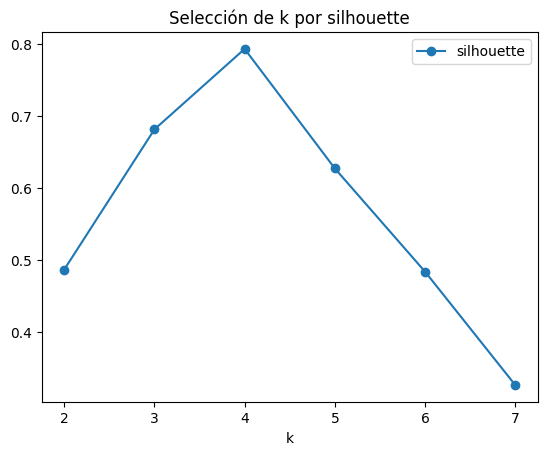

In [2]:
scores = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels = km.fit_predict(X_scaled)
    scores.append({"k": k, "silhouette": silhouette_score(X_scaled, labels)})
scores_df = pd.DataFrame(scores)
display(scores_df)

scores_df.plot(x="k", y="silhouette", marker="o", title="Selección de k por silhouette")
plt.show()

## Perfilado de clusters

In [3]:
k_final = int(scores_df.sort_values("silhouette", ascending=False).iloc[0]["k"])
km = KMeans(n_clusters=k_final, n_init="auto", random_state=42)
df_clustered = df.copy()
df_clustered["cluster"] = km.fit_predict(X_scaled)
display(df_clustered.groupby("cluster").mean().round(2))

,frecuencia,importe_medio,recencia,interacciones
cluster,,,,
0,6.78,-5.65,-6.16,-6.01
1,1.76,4.11,-9.63,9.41
2,-2.63,9.08,4.49,2.08
3,-6.74,-6.85,-8.72,7.18


## PCA para visualización

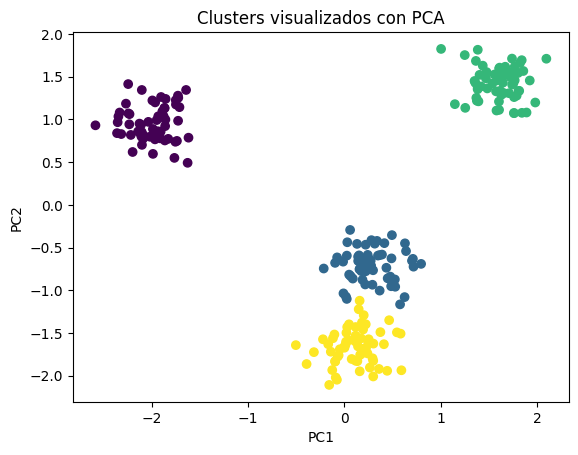

In [4]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
plt.scatter(coords[:,0], coords[:,1], c=df_clustered["cluster"])
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Clusters visualizados con PCA")
plt.show()

## Actividad entregable
1. Modifica el dataset o hiperparámetros.
2. Añade una breve interpretación de resultados.
3. Guarda el notebook ejecutado y exporta una versión HTML/PDF si se solicita.